# DS 6021 — Lab Activity 2: Solution

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
import statsmodels.api as sm

sns.set_theme(style="whitegrid")
rng = np.random.default_rng(6021)      # seed so the bootstrap is reproducible

# set a global variable for the data folder
# Note we have to go up two directories since we are in homework/solutions vs in_class_notebooks. 
DATA = "../../data"                    

In [2]:
# Same rows for every penguin model in this lab.
MEASURES = ["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]

penguins = pd.read_csv(f"{DATA}/penguins.csv")
peng = penguins.dropna(subset=MEASURES).reset_index(drop=True)

print(f"n = {len(peng)}   (dropped {len(penguins) - len(peng)} rows)")
peng.head()

n = 342   (dropped 2 rows)


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007
4,Adelie,Torgersen,39.3,20.6,190.0,3650.0,male,2007


---
# Part 1 — Parameter Estimation and Model Fitting (8 pts)

Predicting `body_mass_g` from `bill_depth_mm`.

### 1a [2 pts] Scatterplot with fitted line

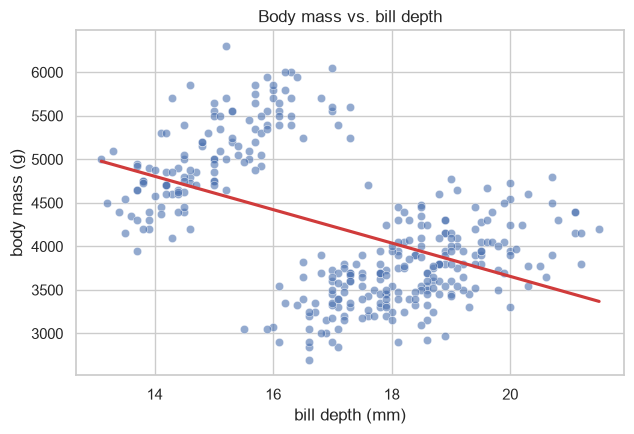

In [3]:
plt.figure(figsize=(6.5, 4.5))
sns.scatterplot(data=peng, x="bill_depth_mm", y="body_mass_g", alpha=0.6)
sns.regplot(data=peng, x="bill_depth_mm", y="body_mass_g", ci=None,
            scatter=False, line_kws={"color": "#d03b3b"})
plt.xlabel("bill depth (mm)"); plt.ylabel("body mass (g)")
plt.title("Body mass vs. bill depth")
plt.tight_layout(); plt.show()

**1a continued.**

The slope of the line is negative/downward, indicating that a deeper bill → lighter penguin.

This is somewhat surprising. I would have expected a deeper bill to correspond to a larger penguin 
(Note: Any answer regarding your expectation is acceptable, maybe you have insight into penguins and would have predicted this. )

### 1b [3 pts] $b_0$ and $b_1$ by hand

In [4]:
x = peng["bill_depth_mm"].to_numpy()
y = peng["body_mass_g"].to_numpy()
n = len(x)
x_bar, y_bar = x.mean(), y.mean()

b1 = ((x - x_bar) * (y - y_bar)).sum() / ((x - x_bar) ** 2).sum()
b0 = y_bar - b1 * x_bar

print(f"b1 = {b1:.4f}")
print(f"b0 = {b0:.4f}")
print()
print(f"body_mass_g = {b0:.2f} + ({b1:.2f}) * bill_depth_mm")

b1 = -191.6428
b0 = 7488.6524

body_mass_g = 7488.65 + (-191.64) * bill_depth_mm


**1b continued.** 

Regression equation: $\text{mass} = 7488.65 - 191.64 \times \text{bill depth}$

Each extra mm of bill depth is associated with about **192 g less** in body mass, on average across all penguins. 

### 1c [3 pts] RSE from the slide 35 formula; $R^2$ from the correlation between bill depth and body mass

In [31]:
# Note: We are using the x and y numpy arrays as defined above
y_hat = b0 + b1 * x
residuals = y - y_hat

# Slide 35:  RSE = sqrt( RSS / (n - 2) ),  RSS = sum of squared residuals
RSS = (residuals ** 2).sum()
RSE = np.sqrt(RSS / (n - 2))

# Correlation (r) between bill depth and body mass
r  = peng["body_mass_g"].corr(peng["bill_depth_mm"])

# R^2 from the correlation: for SIMPLE linear regression, R^2 = r^2  (slide 37)
R2_from_r = r ** 2

# Cross-check against the definitional form, 1 - RSS/TSS
TSS = ((y - y_bar) ** 2).sum()
R2_from_rss = 1 - RSS / TSS

print(f"RSS               = {RSS:,.1f}")
print(f"RSE = sqrt(RSS/(n-2)) = {RSE:.2f}")
print()
print(f"R^2 = r^2         = {R2_from_r:.4f}")
print(f"R^2 = 1 - RSS/TSS = {R2_from_rss:.4f}")


RSS               = 170,466,918.4
RSE = sqrt(RSS/(n-2)) = 708.08

R^2 = r^2         = 0.2227
R^2 = 1 - RSS/TSS = 0.2227


**1c continued** RSE = **708.08**, $R^2$ = **0.2227** (and $r^2 = R^2$ exactly, as it must for
simple linear regression).

**RSE** is the measure of lack of fit of this model, in grams. The calculated value means that we are about 708 g off of the thing we are predicting. 

**$R^2$** is the share of variance explained by the model. 0.22 indicates that most of the variance in this model is not explained by the model itself. 

Both RSE and $R^2$ indicate that this is not a very good model.

---
# Part 2 — How Good Is This Model? (12 pts)

### 2a [2 pts] statsmodels fit; SE, $t$, $p$ for the slope

In [32]:
X = sm.add_constant(peng["bill_depth_mm"])
model_depth = sm.OLS(peng["body_mass_g"], X).fit()

In [34]:
print(f"b1      = {model_depth.params.iloc[1]:.4f}")
print(f"SE(b1)  = {model_depth.bse.iloc[1]:.4f}")
print(f"t       = {model_depth.tvalues.iloc[1]:.4f}   (df = {int(model_depth.df_resid)})")
print(f"p       = {model_depth.pvalues.iloc[1]:.4e}")

b1      = -191.6428
SE(b1)  = 19.4170
t       = -9.8699   (df = 340)
p       = 2.2769e-20


The t-statistic (-9.87) for bill depth is to test the null hypothesis, that there is no linear relationship between bill depth and body mass. The alternative hypothesis is that there IS a linear relationship between bill depth and body mass. Because the p-value is so low, we reject the null hypothesis, and state that there is a statistically significant relationship between bill depth and mass.


### 2b [3 pts] $R^2$ vs. the $p$-value

As we saw when we looked at the 1970 lottery example in class, the $R^2$ value for the model was quite low, but there was a statistically significant slope in the data. 

We are seeing something similar here. Our $R^2$ value of 0.22 indicates that most of the variability we are seeing is not explained by this model. Our low p-value for the slope ($2.27 X10^{-20}$) indicates that this is there is still a strong relationship between mass and bill depth. 

Although at first this might seem contradictory, these two numbers are consistent with one another

### 2c [7 pts] Bootstrap the coefficients

This part of the problem is intended to explore the following question: How long should we run a bootstrap? 


In [8]:
# Here is a function to run the bootstrap
def bootstrap_coefs(x, y, n_boot, seed=6021):
    'Resample rows with replacement; refit b0, b1 on each resample.'
    gen = np.random.default_rng(seed)
    n = len(x)
    out = np.empty((n_boot, 2))
    for i in range(n_boot):
        idx = gen.integers(0, n, n)          # sample n rows WITH replacement
        xb, yb = x[idx], y[idx]              # keep (x, y) pairs together
        xm, ym = xb.mean(), yb.mean()
        slope = ((xb - xm) * (yb - ym)).sum() / ((xb - xm) ** 2).sum()
        out[i] = (ym - slope * xm, slope)
    return pd.DataFrame(out, columns=["b0", "b1"])

# Here is the bootstrap run 10000 times
boot = bootstrap_coefs(x, y, 10000)
boot.describe().round(3)


,b0,b1
count,10000.000,10000.000
mean,7495.024,-192.019
std,275.895,15.558
min,6593.125,-253.891
25%,7305.440,-202.306
50%,7489.786,-191.654
75%,7679.907,-181.302
max,8558.222,-141.512


In [9]:
# Now let's grab the confidence intervals from stats models
analytic_ci = model_depth.conf_int().to_numpy()

# Build a table to compare statsmodels results with the ones from our bootstrap
rows = []
for j, coef in enumerate(["b0", "b1"]):
    lo_b, hi_b = boot[coef].quantile([0.025, 0.975])
    lo_f, hi_f = analytic_ci[j]
    rows.append({"coef": coef,
                 "boot 2.5%": lo_b, "boot 97.5%": hi_b, "boot width": hi_b - lo_b,
                 "sm 2.5%": lo_f, "sm 97.5%": hi_f, "sm width": hi_f - lo_f})
pd.DataFrame(rows).set_index("coef").round(3).T

coef,b0,b1
boot 2.5%,6971.817,-223.456
boot 97.5%,8050.140,-162.465
boot width,1078.322,60.991
sm 2.5%,6829.290,-229.835
sm 97.5%,8148.014,-153.450
sm width,1318.724,76.385


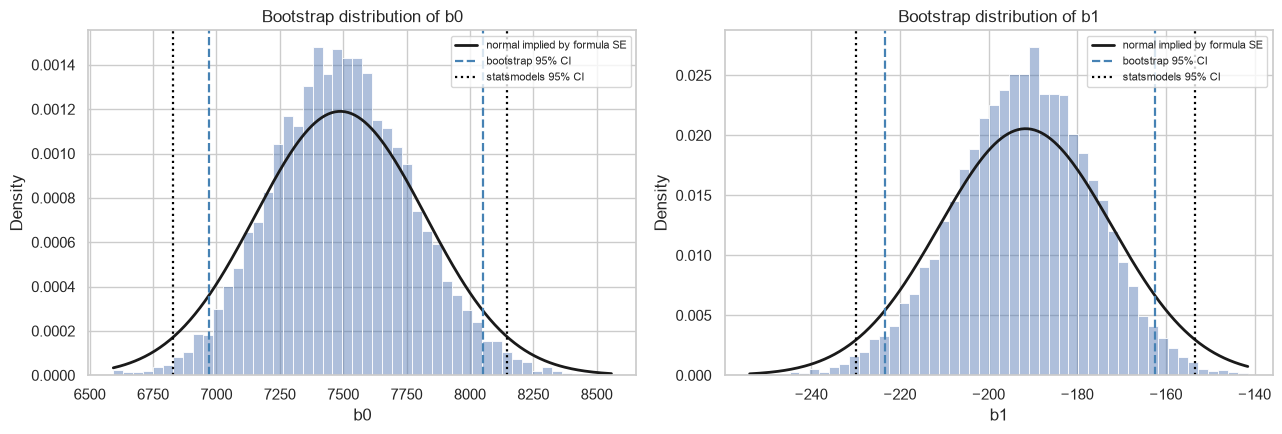

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for j, (ax, coef, est) in enumerate(zip(axes, ["b0", "b1"], [b0, b1])):
    sns.histplot(boot[coef], bins=50, stat="density", ax=ax, alpha=0.45)
    grid = np.linspace(boot[coef].min(), boot[coef].max(), 300)
    ax.plot(grid, stats.norm.pdf(grid, est, model_depth.bse.iloc[j]), "k-", lw=2,
            label="normal implied by formula SE")
    lo, hi = boot[coef].quantile([0.025, 0.975])
    ax.axvline(lo, color="steelblue", ls="--", lw=1.6, label="bootstrap 95% CI")
    ax.axvline(hi, color="steelblue", ls="--", lw=1.6)
    ax.axvline(analytic_ci[j, 0], color="black", ls=":", lw=1.6, label="statsmodels 95% CI")
    ax.axvline(analytic_ci[j, 1], color="black", ls=":", lw=1.6)
    ax.set_title(f"Bootstrap distribution of {coef}"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

| coefficient | statsmodels 95% CI | bootstrap 95% CI |
|---|---|---|
| $b_0$ | [6829.3, 8148.0] — width 1319 | [6971.8, 8050.1] — width 1078 |
| $b_1$ | [−229.8, −153.5] — width 76.4 | [−223.5, −162.5] — width 61.0 |



#### (a) Which is narrower, and what does that tell you?

**The bootstrap is narrower** for both coefficients. This indicates that the formula used in statsmodels may be overestimating the error. 

#### (b) What does the formula assume that the bootstrap does not?

1. **Normally distributed errors** — bootstrap makes no distributional assumption.
2. **Constant error variance (homoscedasticity)**  
3. **An assumed symmetric sampling distribution**, since $\pm t\cdot\text{SE}$ is symmetric by construction

#### (c) [3 pts] Repeat the sampling for B=100, B=1000, and B=10000

In [11]:
rows = []
for n_boot in [100, 1000, 10000]:
    for run in range(1, 11):
        b = bootstrap_coefs(x, y, n_boot, seed=None)
        b0_lo, b0_hi = b["b0"].quantile([0.025, 0.975])
        b1_lo, b1_hi = b["b1"].quantile([0.025, 0.975])
        rows.append({
            "n_boot": n_boot,
            "run": run,
            "b0_mean": b["b0"].mean(),
            "b0_95%_CI": f"[{b0_lo:.4f}, {b0_hi:.4f}]",
            "b0_CI_width": b0_hi - b0_lo,
            "b1_mean": b["b1"].mean(),
            "b1_95%_CI": f"[{b1_lo:.4f}, {b1_hi:.4f}]",
            "b1_CI_width": b1_hi - b1_lo,
        })

pd.DataFrame(rows).set_index(["n_boot", "run"])

b0_mean               b0_95%_CI  b0_CI_width     b1_mean  \
n_boot run                                                                 
100    1    7502.287812  [7060.2626, 7912.7492]   852.486654 -192.602775   
       2    7496.459740  [6955.8708, 8045.9044]  1090.033584 -191.964683   
       3    7470.093444  [6963.2160, 7986.9330]  1023.716960 -190.683209   
       4    7475.043076  [6911.2831, 7946.6837]  1035.400653 -190.813326   
       5    7528.235142  [7079.5430, 8130.2460]  1050.702915 -193.987498   
       6    7426.349771  [7021.7005, 7903.9188]   882.218340 -188.413056   
       7    7502.440698  [7015.1685, 8044.5908]  1029.422305 -192.665341   
       8    7472.895612  [7020.9240, 8018.5567]   997.632726 -190.866199   
       9    7468.010537  [6983.2953, 8065.6393]  1082.343955 -190.500278   
       10   7459.898708  [6958.7252, 8026.7865]  1068.061360 -190.189527   
1000   1    7484.594291  [6963.6861, 7989.3423]  1025.656216 -191.467609   
       2    7486.984081  [6970.8577, 7997.4899]  1026.632182 -191.615149   
       3    7495.283632  [6985.4175, 8043.3489]  1057.931459 -192.124157   
       4    7498.148094  [7007.1153, 8001.3351]   994.219813 -192.239946   
       5    7494.408042  [6967.7703, 8023.1689]  1055.398619 -191.972435   
       6    7486.757293  [6932.0330, 8036.1202]  1104.087212 -191.705713   
       7    7502.425432  [6962.4542, 8010.4691]  1048.014951 -192.385100   
       8    7491.575446  [6954.5661, 8026.6441]  1072.077979 -191.806194   
       9    7500.295252  [6984.4314, 8029.3019]  1044.870566 -192.313685   
       10   7484.342190  [6971.5462, 8044.3557]  1072.809488 -191.491087   
10000  1    7498.629937  [6953.4165, 8057.2468]  1103.830294 -192.248970   
       2    7489.353325  [6957.5573, 8033.0444]  1075.487143 -191.735726   
       3    7495.792859  [6957.3894, 8055.6355]  1098.246089 -192.053176   
       4    7497.153815  [6961.4406, 8031.1063]  1069.665671 -192.128208   
       5    7499.122675  [6965.3967, 8036.4130]  1071.016264 -192.305212   
       6    7496.770002  [6972.4627, 8038.9574]  1066.494669 -192.113088   
       7    7492.965034  [6963.8676, 8039.0932]  1075.225616 -191.967705   
       8    7490.420935  [6953.9465, 8039.5256]  1085.579086 -191.799601   
       9    7496.795558  [6959.8680, 8049.0124]  1089.144413 -192.157900   
       10   7488.624732  [6953.2208, 8045.7805]  1092.559683 -191.664319   

                         b1_95%_CI  b1_CI_width  
n_boot run                                       
100    1    [-217.1073, -166.1457]    50.961527  
       2    [-221.1252, -162.0451]    59.080061  
       3    [-220.8840, -163.6623]    57.221714  
       4    [-219.2091, -157.7387]    61.470441  
       5    [-226.9327, -170.7951]    56.137625  
       6    [-216.1105, -165.6025]    50.508014  
       7    [-222.4867, -166.8825]    55.604183  
       8    [-224.1275, -165.0667]    59.060810  
       9    [-224.3575, -161.7057]    62.651836  
       10   [-221.5058, -163.9196]    57.586266  
1000   1    [-220.6992, -162.4595]    58.239685  
       2    [-219.9543, -163.0437]    56.910559  
       3    [-223.2093, -164.0850]    59.124246  
       4    [-220.5660, -163.7381]    56.827947  
       5    [-222.3219, -162.6890]    59.632935  
       6    [-223.3325, -160.7058]    62.626658  
       7    [-221.0217, -162.3606]    58.661031  
       8    [-222.7242, -162.0684]    60.655768  
       9    [-222.6137, -163.8622]    58.751426  
       10   [-222.6536, -162.6769]    59.976706  
10000  1    [-224.3831, -161.9603]    62.422804  
       2    [-222.8295, -162.1670]    60.662510  
       3    [-223.5907, -162.2002]    61.390411  
       4    [-222.6218, -162.2465]    60.375341  
       5    [-222.8186, -162.5990]    60.219607  
       6    [-222.3729, -162.8671]    59.505817  
       7    [-222.8380, -162.4822]    60.355776  
       8    [-223.0212, -162.1658]    60.855408  
       9    [-223.5281, -161.8144]    61.713786  
       10   [-223.2727, -161.6217

**Answer d.** 

For all of the simulations we ran, whether B=100, B=1000, or B=10,000, we get very similar mean values for both coefficients. All of these runs support the same conclusions about the penguins. This is not surprising, since B is the number times we do the bootstrap, NOT the number of samples in our overall population. 

What is different is how much the confidence intervals change. For example, if we look at B=100, the lower bound of the confidence interval for b1 ranges from around -217 to -227. This varies each time I run this, but the range is much larger than B=1000 or B=10000. For larger values of B, the upper and lower bounds and ranges of the confidence intervals themselves vary much less. If you did not do enough bootstrap samples, you would not get a good estimate for the confidence intervals. 

A good rule of thumb is that if your intervals vary by more than the precision you plan to report, you have not run enough resamples. 

Note: Based on the wording of this question, you will get full credit for c and d if you only do the simulation to return b1 and not b0. 


---
# Part 3 — Residuals (12 pts)

### 3a [3 pts] Fitted vs. residuals: bill depth model vs. the flipper model from class

In [12]:
# Rebuild the in-class flipper-length model on the same rows.
model_flip = sm.OLS(peng["body_mass_g"],
                    sm.add_constant(peng["flipper_length_mm"])).fit()
peng["_fitted_flip"] = model_flip.fittedvalues
peng["_resid_flip"] = model_flip.resid

peng["_fitted_depth"] = model_depth.fittedvalues
peng["_resid_depth"] = model_depth.resid

print(f"bill depth model : R^2 = {model_depth.rsquared:.4f}, RSE = {np.sqrt(model_depth.scale):.1f} g")
print(f"flipper model    : R^2 = {model_flip.rsquared:.4f}, RSE = {np.sqrt(model_flip.scale):.1f} g")

bill depth model : R^2 = 0.2227, RSE = 708.1 g
flipper model    : R^2 = 0.7590, RSE = 394.3 g


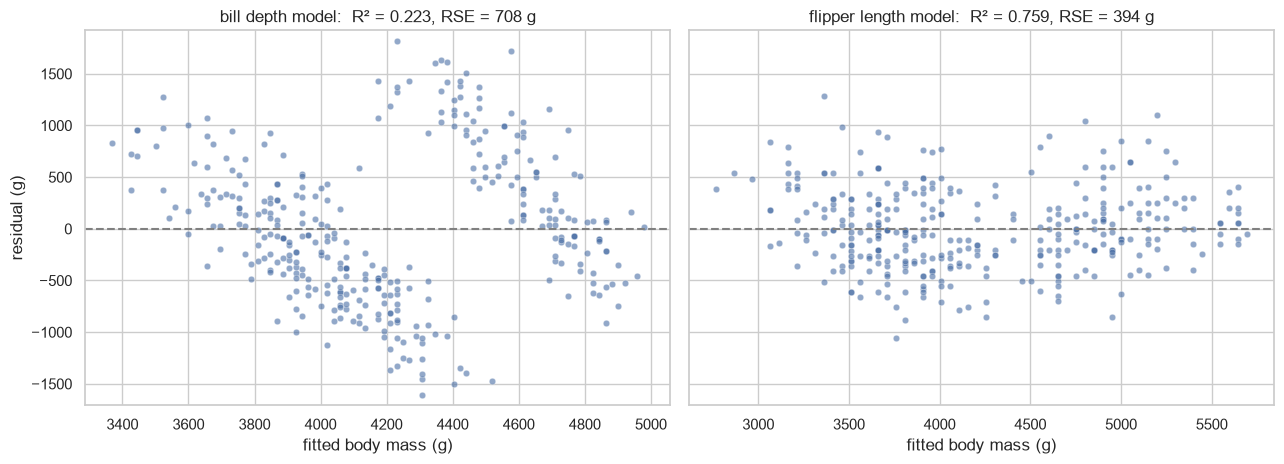

In [13]:
ylim = (min(peng["_resid_depth"].min(), peng["_resid_flip"].min()) - 100,
        max(peng["_resid_depth"].max(), peng["_resid_flip"].max()) + 100)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), sharey=True)
for ax, fcol, rcol, title, m in [
    (axes[0], "_fitted_depth", "_resid_depth", "bill depth model", model_depth),
    (axes[1], "_fitted_flip", "_resid_flip", "flipper length model", model_flip),
]:
    sns.scatterplot(data=peng, x=fcol, y=rcol, alpha=0.6, s=22, color="#4a6fa5", ax=ax)
    ax.axhline(0, color="gray", ls="--")
    ax.set_ylim(ylim)
    ax.set_xlabel("fitted body mass (g)"); ax.set_ylabel("residual (g)")
    ax.set_title(f"{title}:  R² = {m.rsquared:.3f}, RSE = {np.sqrt(m.scale):.0f} g")
plt.tight_layout(); plt.show()

**3a continued**

**Bill depth ($R^2 = 0.223$, RSE 708 g)**: The residuals are not randomly scattered around the x-axis. They form two separate bands: a left band (fitted about 3,400–4,500 g) mostly below zero, and a right band (about 4,200–5,000 g) mostly above zero. Within each band, the residuals slope downward as the fitted value goes up. This isn't curvature, but it demonstrates a clear structure to the residual plot. The errors can be predicted from the fitted value, and they differ systematically between groups. 

**Flipper length ($R^2 = 0.759$, RSE 394 g)**: The fitted values cover a more realistic range of penguin masses. (Note that the x-axis ranges from $< 3000$ to $>5500$ which is a larger range than the bill depth plot.) The residuals form one band of roughly even height around zero, about half as tall as the bill depth band, with no clear trend or systemic structure. This is the much better model.

### 3b [2 pts] The same residuals, colored by species

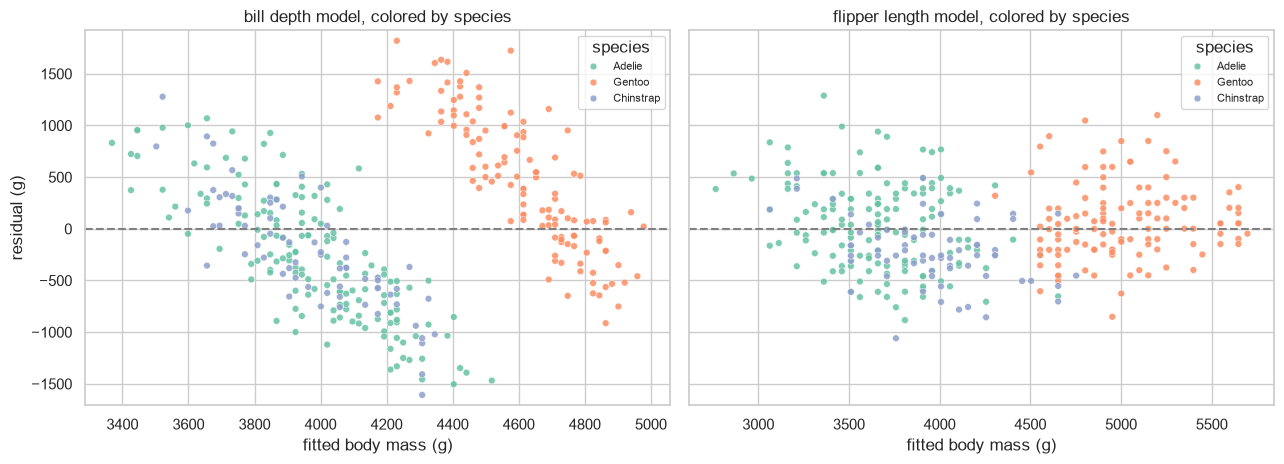

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), sharey=True)
for ax, fcol, rcol, title in [
    (axes[0], "_fitted_depth", "_resid_depth", "bill depth model"),
    (axes[1], "_fitted_flip", "_resid_flip", "flipper length model"),
]:
    sns.scatterplot(data=peng, x=fcol, y=rcol, hue="species", palette="Set2",
                    alpha=0.85, s=24, ax=ax)
    ax.axhline(0, color="gray", ls="--"); ax.set_ylim(ylim)
    ax.set_xlabel("fitted body mass (g)"); ax.set_ylabel("residual (g)")
    ax.set_title(f"{title}, colored by species")
    ax.legend(title="species", fontsize=8)
plt.tight_layout(); plt.show()

**3b**

The bill depth model is **systematically biased by species** and species is the missing variable that we observed in 3a. The bill depth model under-predicts most Gentoo penguins. We observe that the residuals for most Gentoos are greater than zero, which means $y_i - \hat{y} > 0$, and so the predicted $\hat{y}$ is less than the actual value for many of these penguins. The opposite is true for the Adelies and Chinstraps, most of which have residuals that lie below $x=0$. 


The flipper model is better behaved, though we can see that there is a clear separation between the Gentoo population and the Adelies/Chinstraps, which cluster together. In addition, the most of the residuals for the Chinstraps are below zero, indicating overestimation of mass for this population

### 3c [2 pts] Correlation overall vs. within species

In [15]:
overall = peng["bill_depth_mm"].corr(peng["body_mass_g"])

r_by_species = (peng.groupby("species")[["bill_depth_mm", "body_mass_g"]]
                .apply(lambda g: g["bill_depth_mm"].corr(g["body_mass_g"])))

print(f"Correlation across all species:  r = {overall:+.4f}\n")
print("Correlation within each species:")
print(r_by_species.round(3).to_string())

Correlation across all species:  r = -0.4719

Correlation within each species:
species
Adelie       0.576
Chinstrap    0.604
Gentoo       0.719


**3c**

| group | n | r |
|---|---|---|
| **all penguins** | 342 | **−0.472** |
| Adelie | 151 | +0.576 |
| Chinstrap | 68 | +0.605 |
| Gentoo | 123 | +0.719 |

We are observing something called **Simpson's paradox.** This is the phenomenon where a trend appears in several groups of data, but reverses or disappears when they are combined. In this case, Gentoos are much heavier than the other penguins *and* have much shallower bills. This means that when we combine all of the penguins together, we are mostly looking at Gentoo vs Adelie/Chinstrap. This contrast is big enough to flip the sign from positive to negative. 

The plot below shows this more explicitly, though is not required to get full credit on this question. 

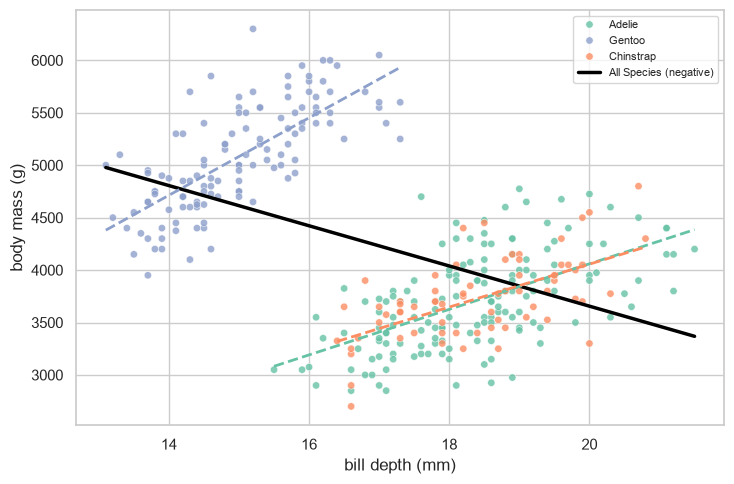

In [16]:
species_colors = dict(zip(sorted(peng["species"].unique()), sns.color_palette("Set2")))

plt.figure(figsize=(7.5, 5))
ax = sns.scatterplot(data=peng, x="bill_depth_mm", y="body_mass_g",
                     hue="species", palette=species_colors, alpha=0.8, s=28)
xs = np.linspace(peng["bill_depth_mm"].min(), peng["bill_depth_mm"].max(), 100)
ax.plot(xs, b0 + b1 * xs, color="black", lw=2.5, label="All Species (negative)")
for sp, g in peng.groupby("species"):
    coef = np.polyfit(g["bill_depth_mm"], g["body_mass_g"], 1)
    gx = np.linspace(g["bill_depth_mm"].min(), g["bill_depth_mm"].max(), 50)
    ax.plot(gx, np.polyval(coef, gx), lw=2, ls="--", color=species_colors[sp])
ax.set_xlabel("bill depth (mm)"); ax.set_ylabel("body mass (g)")
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

### 3d [5 pts] Adelie penguins only

In [35]:
adelie = peng[peng["species"] == "Adelie"].copy()

model_adelie = sm.OLS(adelie["body_mass_g"],
                      sm.add_constant(adelie["bill_depth_mm"])).fit()

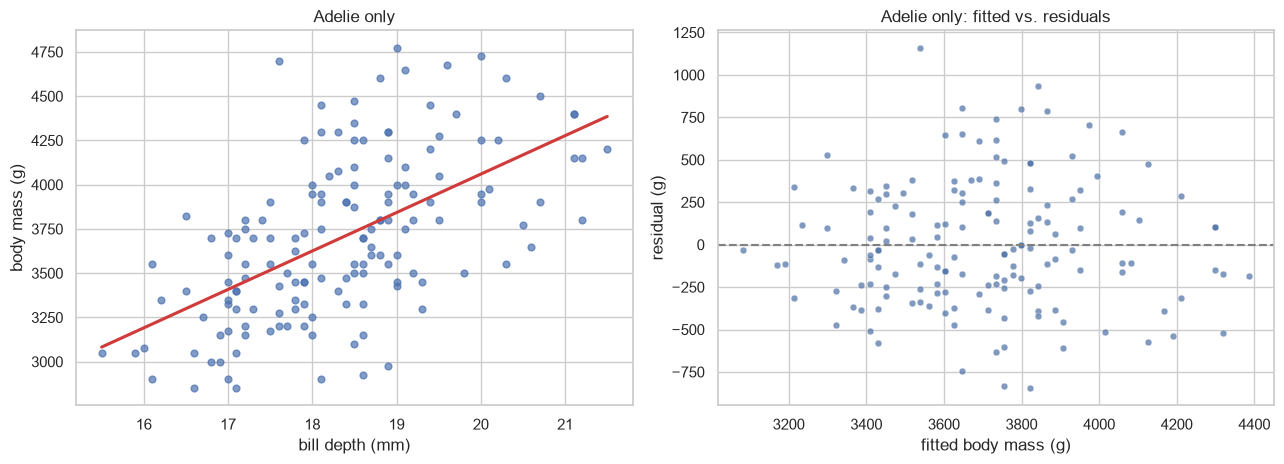

In [36]:
adelie["_fitted"] = model_adelie.fittedvalues
adelie["_resid"] = model_adelie.resid

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

sns.regplot(data=adelie, x="bill_depth_mm", y="body_mass_g", ci=None, ax=axes[0],
            scatter_kws={"s": 24, "alpha": 0.7}, line_kws={"color": "#d03b3b"})
axes[0].set_xlabel("bill depth (mm)"); axes[0].set_ylabel("body mass (g)")
axes[0].set_title(f"Adelie only")

sns.scatterplot(data=adelie, x="_fitted", y="_resid", alpha=0.7, s=24,
                color="#4a6fa5", ax=axes[1])
axes[1].axhline(0, color="gray", ls="--")
axes[1].set_xlabel("fitted body mass (g)"); axes[1].set_ylabel("residual (g)")
axes[1].set_title("Adelie only: fitted vs. residuals")

plt.tight_layout(); plt.show()

**3d**

$$\widehat{\text{mass}} = -283.28 + 217.15 \times \text{bill depth} \qquad (n=151)$$

- Slope **+217.15 g/mm**, SE 25.24, $t = 8.60$, $p = 9.9\times10^{-15}$, 95% CI [167.3, 267.0].
- $R^2 = 0.332$ — *higher* than the pooled model's 0.223. RSE 376 g — nearly half the pooled 708 g.
- Residual plot is a structureless band around zero: no curvature, no clumps, roughly even spread.
  Compare Part 3.2, where the pooled model's residuals separated by species.

**Conclusions for Adelies:** among Adelie penguins, deeper-billed birds are heavier, by about
217 g per mm. This is the opposite of what we saw when considering all penguins as a group. If we ignored species, we'd conclude that lower bill depth was predictive of higher mass. Additionally, although $R^2 = 0.332$ indicates that something else is causing the variability in this model, the linear model is not unreasonable for the Adelies alone. 

Species is an example of a confounding variable. 



---
# Part 4 — Multiple Linear Regression (8 pts)

### 4a [2 pts] Why do $R^2$ and adjusted $R^2$ behave differently?

**Answer.**

$$R^2 = 1 - \frac{\text{RSS}}{\text{TSS}}
\qquad\qquad
R^2_{adj} = 1 - \frac{\text{RSS}/(n-d-1)}{\text{TSS}/(n-1)}$$

$R^2$ measures the proportion of variance explained by the model, and it always increases when more predictors are added. Adjusted $R^2$ accounts for degrees of freedom in the model and can decrease if a new predictor does not improve the model. For that reason, Adjusted $R^2$ is considered a more appropriate choice in selecting the model. 

### 4b [3 pts] Three nested models

In [19]:
specs = [
    ["flipper_length_mm"],
    ["flipper_length_mm", "bill_depth_mm"],
    ["flipper_length_mm", "bill_depth_mm", "bill_length_mm"],
]

fitted_models = []
rows = []
for cols in specs:
    m = sm.OLS(peng["body_mass_g"], sm.add_constant(peng[cols])).fit()
    fitted_models.append(m)
    rows.append({"predictors": " + ".join(c.replace("_mm", "") for c in cols),
                 "d": len(cols), "R^2": m.rsquared, "Adj R^2": m.rsquared_adj,
                 "RSE": np.sqrt(m.scale), "F": m.fvalue})
pd.DataFrame(rows).set_index("predictors").round(4)

,d,R^2,Adj R^2,RSE,F
predictors,,,,,
flipper_length,1,0.7590,0.7583,394.2782,1070.7446
flipper_length + bill_depth,2,0.7610,0.7596,393.1784,539.8239
flipper_length + bill_depth + bill_length,3,0.7615,0.7594,393.4048,359.6718


In [20]:
# Can use this to view the summary of any one of the models
# Fitted_models[2] is the last one in the array with all three predictors.

print(fitted_models[2].summary())

                            OLS Regression Results                            
Dep. Variable:            body_mass_g   R-squared:                       0.761
Model:                            OLS   Adj. R-squared:                  0.759
Method:                 Least Squares   F-statistic:                     359.7
Date:                Wed, 16 Sep 2026   Prob (F-statistic):          8.19e-105
Time:                        21:53:07   Log-Likelihood:                -2526.7
No. Observations:                 342   AIC:                             5061.
Df Residuals:                     338   BIC:                             5077.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const             -6424.7647    561.46

**Which model would you choose and why**


**Choose model 2 (or model 1) — not model 3.** Model 3 has the highest $R^2$ but other metrics suggest it is the worst
of the three: 

- adjusted $R^2$ *falls* (0.7596 → 0.7594) going from two predictors to three and RSE *rises* (393.2 → 393.4). 
- In addition, looking at the model summary for the model with all three predictors, bill length's coefficient is 4.16 with SE 5.33 ($t = 0.78$, $p = 0.44$) indicating that it is not meaningfully adding to the model.

Model 2 vs. model 1 is a close call: bill depth adds 0.002 to $R^2$ and 0.0013 to adjusted
$R^2$, but its own coefficient is not particularly significant ($p = 0.089$). While model 2 does have the best adjusted $R^2$, it adds complexity for not a lot of gain, so either model would be ok. 

### 4c [2 pts] The bill depth coefficient changes sign

In [21]:
print(f"bill_depth coefficient, simple regression      : "
      f"{model_depth.params.iloc[1]:+.3f} ")
print(f"bill_depth coefficient, with flipper_length    : "
      f"{fitted_models[1].params['bill_depth_mm']:+.3f} "
      f"(se {fitted_models[1].bse['bill_depth_mm']:.2f}, "
      f"t {fitted_models[1].tvalues['bill_depth_mm']:.2f}, "
      f"p {fitted_models[1].pvalues['bill_depth_mm']:.4f})")
print()

print(f"\nr(flipper_length, bill_depth) = "
      f"{peng['flipper_length_mm'].corr(peng['bill_depth_mm']):+.4f}")

bill_depth coefficient, simple regression      : -191.643 
bill_depth coefficient, with flipper_length    : +22.634 (se 13.28, t 1.70, p 0.0892)


r(flipper_length, bill_depth) = -0.5839


In [22]:
print(fitted_models[0].summary())

                            OLS Regression Results                            
Dep. Variable:            body_mass_g   R-squared:                       0.759
Model:                            OLS   Adj. R-squared:                  0.758
Method:                 Least Squares   F-statistic:                     1071.
Date:                Wed, 16 Sep 2026   Prob (F-statistic):          4.37e-107
Time:                        21:53:07   Log-Likelihood:                -2528.4
No. Observations:                 342   AIC:                             5061.
Df Residuals:                     340   BIC:                             5069.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const             -5780.8314    305.81

**Answer.** −191.64 → **+22.63**. The sign flips when we include flipper_length as a regressor.

Model with bill_depth only: body_mass_g = 7488.65 + (-191.64)bill_depth_mm
Model with both predictors: mass = -6541.9 + 51.54flipper_length + 22.63bill_depth

For the simple model, change in mass per mm of bill depth compared any penguin to any other penguin, and a 1mm increase in bill_depth decreases the overall mass of the penguins by 191.64 grams. 

For the model with multiple predictors, the change in mass, while holding flipper length fixed, increases by 22.63mm when you increase bill_depth. The difference here is that we are holding flipper length fixed. In the simple model we did not.  

In this particular model, flipper length is a strong proxy for species, which is why we see this behavior. 

### 4d [1 pt] The $F$-statistic in model 3

In [23]:
m3 = fitted_models[2]
print(f"F = {m3.fvalue:.2f} on ({int(m3.df_model)}, {int(m3.df_resid)}) df,  p = {m3.f_pvalue:.3e}")

F = 359.67 on (3, 338) df,  p = 8.189e-105


**Answer.** $F = 359.7$ on $(3, 338)$ df, $p = 8.2\times10^{-105}$.

$$H_0: \beta_{\text{flipper}} = \beta_{\text{bill depth}} = \beta_{\text{bill length}} = 0
\qquad H_a: \text{at least one } \beta_j \neq 0$$

The null hypothesis is that none of the coefficients are significant in predicting body mass. The alternative hypothesis is that at least one coefficient is significant. Based on the F-statistic and p-value, we should reject $H_0$. We can't claim from these numbers WHICH predictor is significant, just that one is. This is true, even though we know from part b that this model is the worst of the three we looked at. 

---
# Part 5 — Modeling with the Planets Dataset (10 pts)

### 5a [2 pts] Linear fit; actual vs. predicted; the four innermost planets

In [24]:
planets = pd.read_csv(f"{DATA}/PlanetsData.csv")

model_raw = sm.OLS(planets["revolution"],
                   sm.add_constant(planets["distance"])).fit()
print(model_raw.summary())

                            OLS Regression Results                            
Dep. Variable:             revolution   R-squared:                       0.978
Model:                            OLS   Adj. R-squared:                  0.975
Method:                 Least Squares   F-statistic:                     312.1
Date:                Wed, 16 Sep 2026   Prob (F-statistic):           4.59e-07
Time:                        21:53:07   Log-Likelihood:                -88.599
No. Observations:                   9   AIC:                             181.2
Df Residuals:                       7   BIC:                             181.6
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -4578.7935   2287.376     -2.002      0.0

In [25]:
planets["fitted_linear"] = model_raw.fittedvalues
planets["resid_linear"] = model_raw.resid

print(f"revolution = {model_raw.params.iloc[0]:.2f} + "
      f"{model_raw.params.iloc[1]:.4f} * distance")
print(f"R^2 = {model_raw.rsquared:.4f}\n")

planets[["planet", "distance", "revolution", "fitted_linear", "resid_linear"]].round(1)

revolution = -4578.79 + 24.0957 * distance
R^2 = 0.9781



,planet,distance,revolution,fitted_linear,resid_linear
0,Mercury,36,88,-3711.3,3799.3
1,Venus,67,225,-2964.4,3189.4
2,Earth,93,365,-2337.9,2702.9
3,Mars,142,687,-1157.2,1844.2
4,Jupiter,484,4332,7083.5,-2751.5
5,Saturn,887,10760,16794.1,-6034.1
6,Uranus,1765,30684,37950.1,-7266.1
7,Neptune,2791,60188,62672.3,-2484.3
8,Pluto,3654,90467,83466.9,7000.1


**Answer.** 

Based on $R^2$ alone this model looks excellent — 97.8% of variance explained, slope significant at
$p = 4.6\times10^{-7}$.

However, when we look at the first four planets, this model predicts negative orbital periods, which is completely non-sensical. 
 
This illustrates a point we discussed in class. Specifically, $R^2$ alone is not enough to tell you if a model is any good. 

### 5b [2 pts] Fitted vs. residuals

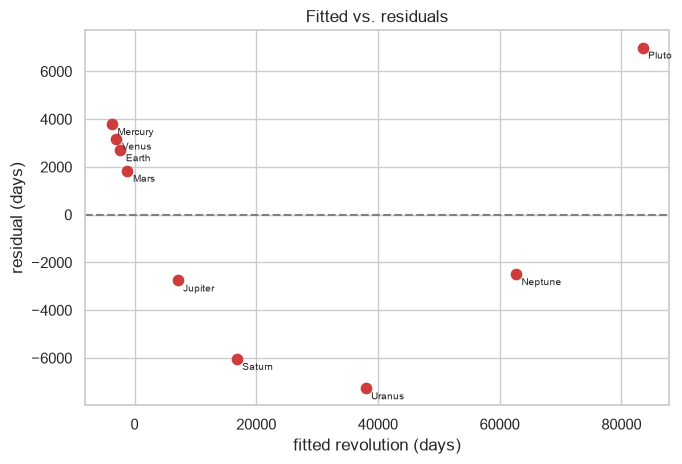

In [26]:
fig, ax = plt.subplots(figsize=(7, 4.8))

ax.scatter(planets["fitted_linear"], planets["resid_linear"], s=55, color="#d03b3b")
ax.axhline(0, color="gray", ls="--")
ax.set_xlabel("fitted revolution (days)"); ax.set_ylabel("residual (days)")
ax.set_title("Fitted vs. residuals")

for _i, row in planets.iterrows():
    ax.annotate(row["planet"], (row["fitted_linear"], row["resid_linear"]),
                fontsize=7.5, xytext=(4, -8), textcoords="offset points")

plt.tight_layout(); plt.show()

**Answer.** 

The residuals have a clear U-shape. This is not random scatter, there is a clear pattern, indicating that a linear model is not appropriate in this case. 

**Largest residuals** (residual = actual − fitted, so negative = model predicted too large):

- **Uranus**, −7,266 days: **over-predicted**
- **Pluto**, +7,000 days: **under-predicted**
- **Saturn**, −6,034 days: **over-predicted**

### 5c [6 pts] Log transformation and Kepler's Third Law

In [27]:
# a) Apply a log transformation to distance and revolution and fit the model
planets["log_distance"] = np.log(planets["distance"])
planets["log_revolution"] = np.log(planets["revolution"])

model_log = sm.OLS(planets["log_revolution"],
                   sm.add_constant(planets["log_distance"])).fit()
print(model_log.summary())

                            OLS Regression Results                            
Dep. Variable:         log_revolution   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 1.585e+06
Date:                Wed, 16 Sep 2026   Prob (F-statistic):           5.26e-20
Time:                        21:53:07   Log-Likelihood:                 34.696
No. Observations:                   9   AIC:                            -65.39
Df Residuals:                       7   BIC:                            -65.00
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const           -0.9031      0.007   -122.147   

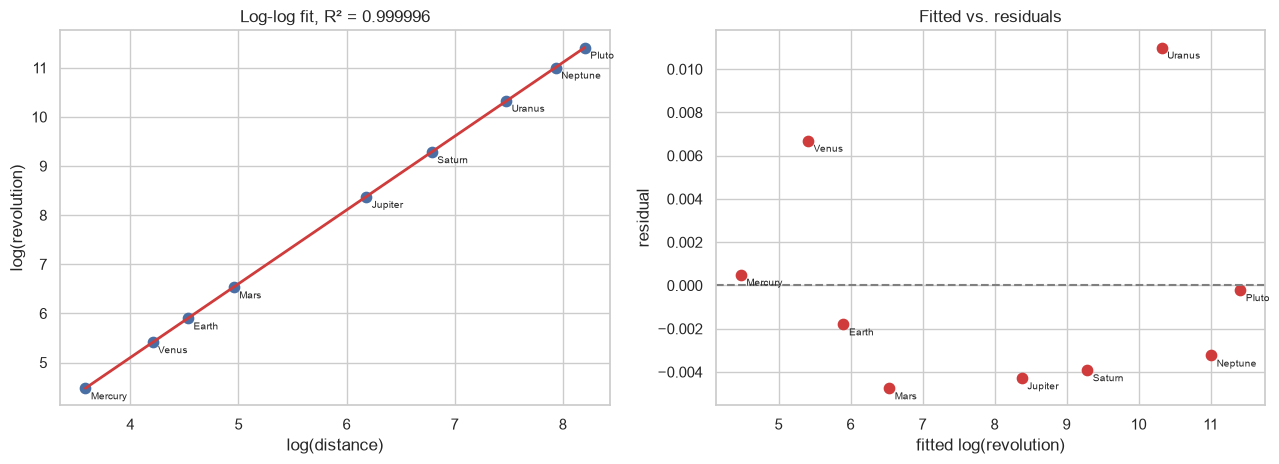

In [28]:
# b) Create a log_log plot. Is this a better fit? 

planets["log_fitted"] = model_log.fittedvalues
planets["log_resid"] = model_log.resid

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

axes[0].scatter(planets["log_distance"], planets["log_revolution"], s=55, color="#4a6fa5")
gx = np.linspace(planets["log_distance"].min(), planets["log_distance"].max(), 100)
axes[0].plot(gx, model_log.params.iloc[0] + model_log.params.iloc[1] * gx,
             color="#d03b3b", lw=2)
axes[0].set_xlabel("log(distance)"); axes[0].set_ylabel("log(revolution)")
axes[0].set_title(f"Log-log fit, R² = {model_log.rsquared:.6f}")

axes[1].scatter(planets["log_fitted"], planets["log_resid"], s=55, color="#d03b3b")
axes[1].axhline(0, color="gray", ls="--")
axes[1].set_xlabel("fitted log(revolution)"); axes[1].set_ylabel("residual")
axes[1].set_title("Fitted vs. residuals")

for ax, xc, yc in [(axes[0], "log_distance", "log_revolution"),
                   (axes[1], "log_fitted", "log_resid")]:
    for _i, row in planets.iterrows():
        ax.annotate(row["planet"], (row[xc], row[yc]),
                    fontsize=7.5, xytext=(4, -8), textcoords="offset points")

plt.tight_layout(); plt.show()

**Answer (b).** Yes, this is a significantly better model. The log–log scatter is a straight line to the eye,
and the residuals no longer show  a distinct U-shape.

**(c)** Report $R^2$ and the slope; identify the fraction; derive Kepler's Third Law.

In [29]:
b0_log = model_log.params.iloc[0]
b1_log = model_log.params.iloc[1]
ci_lo, ci_hi = model_log.conf_int().to_numpy()[1]

print(f"log(revolution) = {b0_log:.4f} + {b1_log:.4f} * log(distance)")
print(f"R^2   = {model_log.rsquared:.6f}    (linear model was {model_raw.rsquared:.4f})")
print(f"slope = {b1_log:.4f} ")

log(revolution) = -0.9031 + 1.5013 * log(distance)
R^2   = 0.999996    (linear model was 0.9781)
slope = 1.5013 


**Answer (c).** 

$R^2 = 0.999996$
slope $= 1.5013$. 

This is very close to 3/2. 

We can take the fitted equation with the slope at its exact value $3/2$, and write:

$$\log(R) = b_0 + \tfrac{3}{2}\log(D)$$

Note we are using shorthand where R = revolution and D = distance. We are writing b0 as a variable rather than filling in the value. 

Now we exponentiate both sides:

$$R = e^{b_0}\, D^{3/2} = k\, D^{3/2}$$

Note: We know that $e^{b_0}$ is a constant, which we are rewriting as k. We could calculate it directly from our model. ($e^{-0.9301}$)

We now square the equation to come to Kepler's third law:

$$R^2 = k^2 D^3$$

$$\boxed{\;\text{revolution}^2 \propto \text{distance}^3\;}$$

**(d)** Actual vs. fitted revolution under the new model, compared to the linear model.

In [30]:

planets["fitted_loglog"] = np.exp(model_log.fittedvalues)   # back to days

compare = planets[["planet", "revolution", "fitted_linear", "fitted_loglog"]].copy()

compare

,planet,revolution,fitted_linear,fitted_loglog
0,Mercury,88,-3711.348645,87.955672
1,Venus,225,-2964.382280,223.498426
2,Earth,365,-2337.894361,365.655904
3,Mars,687,-1157.205590,690.272590
4,Jupiter,4332,7083.520113,4350.622150
5,Saturn,10760,16794.082858,10802.199220
6,Uranus,30684,37950.097969,30348.267640
7,Neptune,60188,62672.275081,60383.237531
8,Pluto,90467,83466.854854,90486.168764


**Answer (d).** The new model does a significantly better job at modeling reality. 